# Лабораторная работа №2
## Классификация данных

Цель работы: изучение методов машинного обучения для решения задачи классификации.

В работе используется набор данных о состоянии и эксплуатации автомобильных аккумуляторных батарей.

Целевая переменная — `battery_failure`:
- `0` — отказ батареи отсутствует;
- `1` — произошёл отказ батареи.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("vehicles_normal.csv")
df.head()

,battery_capacity_kwh,odometer_km,battery_health_percent,state_of_charge,depth_of_discharge,cell_voltage_avg,cell_voltage_std,pack_voltage,cell_temperature_avg,internal_resistance,...,cooling_system_health,firmware_updates,previous_faults,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,charging_quality_score,driving_stress_score,battery_failure
0,87.315,290844.3,80.60,65.00,58.74,3.793,0.0046,383.09,21.75,0.506,...,84.84,13.0,2.0,1.0,1.0,0.0,30.37,89.730,47.11,0
1,38.710,182239.5,61.24,43.32,35.23,3.744,0.0236,355.68,14.98,0.861,...,81.95,19.0,1.0,0.0,1.0,0.0,67.94,87.935,55.38,0
2,131.290,249369.3,62.35,68.37,59.60,3.514,0.0075,323.29,33.70,0.720,...,81.29,21.0,1.0,0.0,1.0,0.0,74.84,86.840,74.54,0
3,132.350,134830.2,83.41,63.87,60.77,3.664,0.0167,267.47,31.28,0.351,...,94.47,19.0,0.0,1.0,0.0,0.0,46.94,93.930,31.69,0
4,25.720,158026.0,78.49,46.59,37.54,3.600,0.0169,358.30,15.66,0.425,...,90.89,10.0,0.0,1.0,2.0,3.0,49.07,100.000,23.46,0


In [5]:
df.shape

(20000, 34)

In [10]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["battery_failure"].value_counts()

battery_failure
0    18616
1     1384
Name: count, dtype: int64

In [13]:
df["battery_failure"].value_counts(normalize=True)

battery_failure
0    0.9308
1    0.0692
Name: proportion, dtype: float64

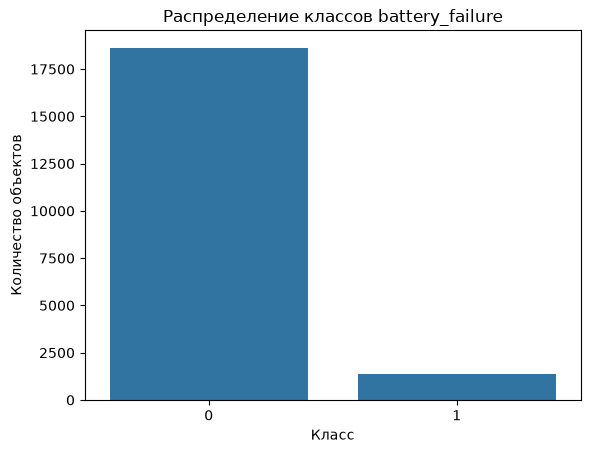

In [14]:
sns.countplot(x="battery_failure", data=df)
plt.title("Распределение классов battery_failure")
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.show()

## Разделение признаков и целевой переменной

Целевая переменная `battery_failure` отделяется от остальных признаков.

`X` содержит признаки объектов, а `y` — целевой класс.

In [15]:
X = df.drop(columns=["battery_failure"])
y = df["battery_failure"]

In [17]:
from sklearn.model_selection import train_test_split

In [74]:
# test_size: Размер тестовой выборки, random_state - фиксирует генератор случайных чисел, stratify - точно такое же 
# соотношение как в исходном файле
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [75]:
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

# показывает, что разпределение по y дало +- одинковую долю

Train:
battery_failure
0    0.930813
1    0.069187
Name: proportion, dtype: float64

Test:
battery_failure
0    0.93075
1    0.06925
Name: proportion, dtype: float64


## Разделение данных на обучающую и тестовую выборки

Набор данных разделяется на обучающую и тестовую выборки в соотношении 80/20.

Для сохранения исходного соотношения классов используется стратифицированное разбиение.

## Метод k-ближайших соседей (KNN)

Перед обучением KNN признаки масштабируются с помощью `StandardScaler`, так как алгоритм основан на вычислении расстояний между объектами.

Для подбора гиперпараметров используется `GridSearchCV`.

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [76]:
# scaler приводит все цифры к одному формату
knn_pipeline = Pipeline([("scaler", StandardScaler()),("knn", KNeighborsClassifier())])

In [77]:
# weights - влияние на удаленность. metric - нахождение расстояния(пифагор, либо движение без диагоналей)
knn_params = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

In [79]:
# перебиратор. cv - кросс-валидация. n_jobs - использовать все ядра
knn_grid = GridSearchCV(estimator=knn_pipeline,param_grid=knn_params,cv=3,scoring="f1",n_jobs=-1)

In [82]:
#обучение.
knn_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__metric': ['euclidean', 'manhattan'], 'knn__n_neighbors': [3, 5, ...], 'knn__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verb

In [26]:
print("Лучшие параметры:")
print(knn_grid.best_params_)

print("Лучший F1 на кросс-валидации:")
print(knn_grid.best_score_)

Лучшие параметры:
{'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
Лучший F1 на кросс-валидации:
0.18653912834266226


In [27]:
from sklearn.metrics import classification_report, confusion_matrix

In [28]:
y_pred_knn = knn_grid.predict(X_test)

In [83]:
# precision - точность предсказывания recall - сколько найдено из всех f1-score   support - сколько объектов в выборке
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97      3723
           1       0.66      0.13      0.22       277

    accuracy                           0.94      4000
   macro avg       0.80      0.56      0.59      4000
weighted avg       0.92      0.94      0.91      4000



In [85]:
# [[TN FP]
# [FN TP]]
print(confusion_matrix(y_test, y_pred_knn))

[[3704   19]
 [ 240   37]]


In [31]:
from sklearn.metrics import roc_auc_score

In [86]:
y_proba_knn = knn_grid.predict_proba(X_test)[:, 1]

roc_auc_knn = roc_auc_score(y_test, y_proba_knn)

# чутка не дотягивает до приемлемого качества ранжирования
print("ROC-AUC:", roc_auc_knn)

ROC-AUC: 0.6868228622738349


### Вывод по модели KNN

После подбора гиперпараметров лучшая модель KNN использует 3 ближайших соседа,
евклидову метрику расстояния и равномерные веса соседей.

На тестовой выборке модель показала высокую общую точность, однако значение
recall для класса отказа батареи оказалось низким. Модель обнаружила только
небольшую часть фактических отказов.

Это связано в том числе с существенным дисбалансом классов в исходном наборе данных.
Значение ROC-AUC составило около 0.69, поэтому качество разделения классов
можно считать умеренным.

## Метод опорных векторов (SVM)

Метод опорных векторов используется для построения границы, разделяющей объекты различных классов.

Перед обучением выполняется стандартизация признаков.
Для подбора гиперпараметров модели используется GridSearchCV.

In [33]:
from sklearn.svm import SVC

In [34]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(class_weight="balanced"))
])

In [35]:
svm_params = [
    {"svm__kernel": ["linear"],   "svm__C": [0.1, 1, 10]},
    {"svm__kernel": ["rbf"],"svm__C": [0.1, 1, 10],"svm__gamma": ["scale", "auto"]}
]

In [36]:
svm_grid = GridSearchCV(estimator=svm_pipeline, param_grid=svm_params,cv=3,scoring="f1",n_jobs=-1)

In [37]:
svm_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'svm__C': [0.1, 1, ...], 'svm__kernel': ['linear']}, {'svm__C': [0.1, 1, ...], 'svm__gamma': ['scale', 'auto'], 'svm__kernel': ['rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.

In [38]:
print("Лучшие параметры:")
print(svm_grid.best_params_)

print("Лучший F1 на кросс-валидации:")
print(svm_grid.best_score_)

Лучшие параметры:
{'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Лучший F1 на кросс-валидации:
0.6442929856134841


In [39]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [40]:
y_pred_svm = svm_grid.predict(X_test)

In [41]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96      3723
           1       0.50      0.75      0.60       277

    accuracy                           0.93      4000
   macro avg       0.74      0.85      0.78      4000
weighted avg       0.95      0.93      0.94      4000



In [42]:
print(confusion_matrix(y_test, y_pred_svm))

[[3517  206]
 [  70  207]]


In [43]:
y_score_svm = svm_grid.decision_function(X_test)

In [44]:
roc_auc_svm = roc_auc_score(y_test, y_score_svm)

In [45]:
print("ROC-AUC:", roc_auc_svm)

ROC-AUC: 0.9587276283343563


### Вывод по модели SVM

После подбора гиперпараметров лучшей оказалась модель SVM с RBF-ядром, `C = 1` и `gamma = scale`.

На тестовой выборке модель показала recall около 0.75 для класса отказа батареи, то есть обнаружила большую часть фактических отказов. F1-score для данного класса составил около 0.60.

ROC-AUC составил около 0.96, что свидетельствует о хорошем разделении классов.

По сравнению с KNN модель SVM значительно лучше обнаруживает отказы батареи.

## Случайный лес (Random Forest)

Random Forest представляет собой ансамбль деревьев решений. Итоговый прогноз формируется на основе результатов множества отдельных деревьев.

Для подбора гиперпараметров используется GridSearchCV.

In [46]:
from sklearn.ensemble import RandomForestClassifier

In [47]:
rf = RandomForestClassifier(random_state=42, class_weight="balanced")

In [48]:
rf_params = {"n_estimators": [100, 200], "max_depth": [None, 10], "min_samples_leaf": [1, 2, 4], "max_features": ["sqrt", "log2"]}

In [49]:
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring="f1", n_jobs=-1)

In [50]:
rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose v

In [51]:
print("Лучшие параметры:", rf_grid.best_params_)
print("Лучший F1 на кросс-валидации:", rf_grid.best_score_)

Лучшие параметры: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 200}
Лучший F1 на кросс-валидации: 0.5924910084557724


In [52]:
y_pred_rf = rf_grid.predict(X_test)

In [53]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96      3723
           1       0.52      0.70      0.60       277

    accuracy                           0.94      4000
   macro avg       0.75      0.83      0.78      4000
weighted avg       0.95      0.94      0.94      4000



In [54]:
print(confusion_matrix(y_test, y_pred_rf))

[[3547  176]
 [  83  194]]


In [55]:
y_proba_rf = rf_grid.predict_proba(X_test)[:, 1]

In [56]:
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
print("ROC-AUC:", roc_auc_rf)

ROC-AUC: 0.9499733823602138


### Вывод по модели Random Forest

После подбора гиперпараметров лучшая модель Random Forest использует 200 деревьев, `max_features = sqrt` и `min_samples_leaf = 4`.

На тестовой выборке модель показала recall около 0.70 и F1-score около 0.60 для класса отказа батареи.

Значение ROC-AUC составило около 0.95, что свидетельствует о высоком качестве разделения классов.

Random Forest значительно превосходит KNN и показывает результат, близкий к SVM.

In [58]:
best_rf = rf_grid.best_estimator_

In [59]:
feature_importance = pd.DataFrame({"Признак": X.columns, "Важность": best_rf.feature_importances_}).sort_values("Важность", ascending=False)

In [60]:
feature_importance.head(10)

,Признак,Важность
8,cell_temperature_avg,0.194756
2,battery_health_percent,0.161014
9,internal_resistance,0.124920
30,battery_stress_index,0.092151
26,previous_faults,0.069570
28,BMS_warning_count,0.048235
24,cooling_system_health,0.023492
1,odometer_km,0.018708
29,abnormal_voltage_events,0.018491
19,average_ambient_temperature,0.015971


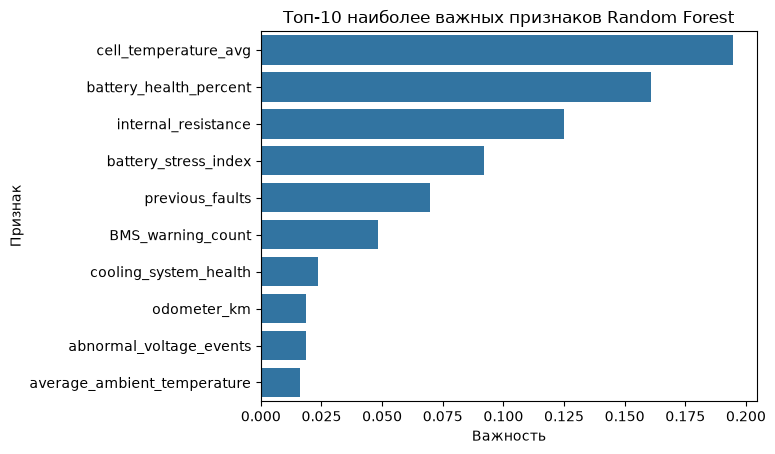

In [62]:
top_features = feature_importance.head(10)
sns.barplot(data=top_features, x="Важность", y="Признак")
plt.title("Топ-10 наиболее важных признаков Random Forest")
plt.show()

### Анализ важности признаков

Наибольшую важность для модели Random Forest получили средняя температура ячеек,
процент здоровья батареи, внутреннее сопротивление и индекс нагрузки батареи.

Также заметный вклад в прогнозирование отказа вносят количество предыдущих неисправностей
и количество предупреждений BMS.

Полученные результаты показывают, что параметры, непосредственно характеризующие
состояние и нагрузку аккумуляторной батареи, являются наиболее информативными для классификации.

In [64]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [65]:
results = pd.DataFrame({
    "Модель": ["KNN", "SVM", "Random Forest"],
    "Precision": [precision_score(y_test, y_pred_knn), precision_score(y_test, y_pred_svm), precision_score(y_test, y_pred_rf)],
    "Recall": [recall_score(y_test, y_pred_knn), recall_score(y_test, y_pred_svm), recall_score(y_test, y_pred_rf)],
    "F1-score": [f1_score(y_test, y_pred_knn), f1_score(y_test, y_pred_svm), f1_score(y_test, y_pred_rf)],
    "ROC-AUC": [roc_auc_knn, roc_auc_svm, roc_auc_rf]
})

In [66]:
results.round(3)

,Модель,Precision,Recall,F1-score,ROC-AUC
0,KNN,0.661,0.134,0.222,0.687
1,SVM,0.501,0.747,0.600,0.959
2,Random Forest,0.524,0.700,0.600,0.950


In [67]:
from sklearn.metrics import roc_curve

In [68]:
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

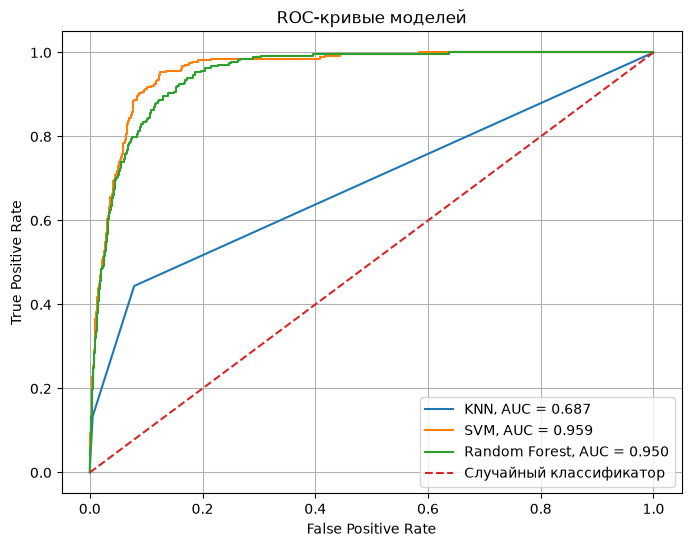

In [69]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, label=f"KNN, AUC = {roc_auc_knn:.3f}")
plt.plot(fpr_svm, tpr_svm, label=f"SVM, AUC = {roc_auc_svm:.3f}")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest, AUC = {roc_auc_rf:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Случайный классификатор")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривые моделей")
plt.legend()
plt.grid()
plt.show()

### Сравнение ROC-кривых

Наилучшее значение ROC-AUC показала модель SVM — около 0.96.

Random Forest показал близкий результат — около 0.95.

KNN значительно уступает двум другим моделям, его ROC-AUC составляет около 0.69.

Таким образом, модели SVM и Random Forest значительно лучше разделяют классы отказа и отсутствия отказа батареи.

## Вывод

В рамках лабораторной работы были обучены и исследованы три модели классификации:
KNN, SVM и Random Forest.

Для каждой модели был выполнен подбор гиперпараметров с использованием GridSearchCV.
Качество моделей оценивалось с использованием precision, recall, F1-score и ROC-AUC.

Наихудший результат показал алгоритм KNN. Несмотря на высокое значение accuracy,
модель обнаруживала лишь небольшую часть реальных отказов батареи.

Модели SVM и Random Forest показали значительно более высокое качество классификации.
Наилучший результат показала модель SVM, которая получила ROC-AUC около 0.96
и recall около 0.75 для класса отказа батареи.

Анализ Feature Importance модели Random Forest показал, что наиболее значимыми признаками
являются средняя температура ячеек, процент здоровья батареи, внутреннее сопротивление,
индекс нагрузки батареи, количество предыдущих неисправностей и предупреждений BMS.

Таким образом, наиболее эффективной моделью для данного набора данных является SVM.